In [1]:
import pandas as pd
import geopandas as gpd
import ee
import geemap
import json
import datetime
import time
import os
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

In [3]:
ee.Authenticate()
ee.Initialize(project='bubbly-operator-479705-v3')  


Successfully saved authorization token.


## 1. Подготовка данных

### 1.1 Выбор года исследования
По данным CSV (degraded_pixels), 2005 год — максимум деградации (26 698 пикселей). Выбираем его.

In [ ]:
fires_df = gpd.read_file('data/fires_irk_mc6mc6v3corr_2005.shp')
print(f'Всего пожаров: {len(fires_df)}')
print(f'Столбцы: {fires_df.columns.tolist()}')
print(f'CRS: {fires_df.crs}')
print(f'\nПервые строки:')
fires_df.head()

In [ ]:
print("=" * 60)
print("ДИАГНОСТИКА ДАННЫХ О ПОЖАРАХ")
print("=" * 60)
print(f"Строк: {len(fires_df)}")
print(f"CRS: {fires_df.crs}")
print(f"Все столбцы:")
for col in fires_df.columns:
    dtype = fires_df[col].dtype
    sample = fires_df[col].iloc[0] if len(fires_df) > 0 else "N/A"
    print(f"  {col:30s} | {str(dtype):10s} | пример: {sample}")
print(f"Площадь (bounds): {fires_df.total_bounds}")
print(f"Типы геометрий: {fires_df.geom_type.unique()}")

### 1.2 Фильтрация пожаров по Иркутской области (локально, экономим GEE)

In [ ]:
irk_obl = gpd.read_file('data/irkutsk_region.geojson')
print(f'Иркутская область загружена. CRS: {irk_obl.crs}')

if fires_df.crs != irk_obl.crs:
    fires_df = fires_df.to_crs(irk_obl.crs)
    print(f'Перепроецирование пожаров в {irk_obl.crs}')

fires_irk = gpd.sjoin(fires_df, irk_obl[['geometry']], predicate='intersects', how='inner')
fires_irk = fires_irk.drop(columns=['index_right'], errors='ignore')
print(f'Пожаров, пересекающих Иркутскую область: {len(fires_irk)}')

print(f'\n--- Статистика площадей ---')
print(f'Мин:    {fires_irk.Area.min()} га')
print(f'Медиана:{fires_irk.Area.median()} га')
print(f'Среднее:{fires_irk.Area.mean():.0f} га')
print(f'Макс:   {fires_irk.Area.max()} га')

AREA_THRESHOLD = 500

fires_irk = fires_irk[fires_irk['Area'] >= AREA_THRESHOLD].copy()
print(f'\nПожаров с Area >= {AREA_THRESHOLD} га: {len(fires_irk)}')

fires_irk['frname'] = 'Иркутская область'

print(f'\nИтого пожаров для анализа: {len(fires_irk)}')
print(f'Общая площадь: {fires_irk.Area.sum():,.0f} га')

In [7]:
fire_id_col = 'fire_id'
date_col_first = 'dt_first'
date_col_last = 'dt_liq'  

fires_irk['dt_first'] = pd.to_datetime(fires_irk['dt_first'])
fires_irk['dt_last'] = pd.to_datetime(fires_irk['dt_last'])
fires_irk['dt_liq'] = pd.to_datetime(fires_irk['dt_liq'])

fires_irk['duration_days'] = (fires_irk['dt_liq'] - fires_irk['dt_first']).dt.days
print(f'Средняя длительность пожара: {fires_irk.duration_days.mean():.1f} дней')
print(f'Пожаров для обработки: {len(fires_irk)}')


Средняя длительность пожара: 7.8 дней
Пожаров для обработки: 159


In [5]:
import glob

other_fires = []
for f in glob.glob('data/fires_irk_mc6mc6v3corr_*.shp'):
    if '2005' not in f:
        gdf = gpd.read_file(f)
        other_fires.append(gdf)
        print(f'{f}: {len(gdf)} пожаров')

if other_fires:
    fires_other = pd.concat(other_fires)
    if fires_other.crs != fires_irk.crs:
        fires_other = fires_other.to_crs(fires_irk.crs)
    
    overlap = gpd.sjoin(fires_irk, fires_other[['geometry']],
                        predicate='intersects', how='left')
    dirty_ids = overlap.dropna(subset=['index_right']).fire_id.unique()
    fires_irk['is_clean'] = ~fires_irk.fire_id.isin(dirty_ids)
    
    print(f'\nС повторными пожарами: {len(dirty_ids)}')
    print(f'"Чистых": {fires_irk.is_clean.sum()}')
else:
    fires_irk['is_clean'] = True
    print('Файлы других лет не найдены')

data\fires_Irk_mc6mc6v3corr_2001.shp: 2630 пожаров
data\fires_Irk_mc6mc6v3corr_2002.shp: 4474 пожаров
data\fires_Irk_mc6mc6v3corr_2003.shp: 13104 пожаров
data\fires_Irk_mc6mc6v3corr_2004.shp: 2357 пожаров
data\fires_Irk_mc6mc6v3corr_2006.shp: 6677 пожаров
data\fires_Irk_mc6mc6v3corr_2007.shp: 7270 пожаров
data\fires_Irk_mc6mc6v3corr_2008.shp: 8335 пожаров
data\fires_Irk_mc6mc6v3corr_2009.shp: 4582 пожаров
data\fires_Irk_mc6mc6v3corr_2010.shp: 3941 пожаров
data\fires_Irk_mc6mc6v3corr_2011.shp: 7229 пожаров
data\fires_Irk_mc6mc6v3corr_2012.shp: 4153 пожаров
data\fires_Irk_mc6mc6v3corr_2013.shp: 4767 пожаров
data\fires_Irk_mc6mc6v3corr_2014.shp: 8558 пожаров
data\fires_Irk_mc6mc6v3corr_2015.shp: 6847 пожаров
data\fires_Irk_mc6mc6v3corr_2016.shp: 5621 пожаров
data\fires_Irk_mc6mc6v3corr_2017.shp: 4895 пожаров
data\fires_Irk_mc6mc6v3corr_2018.shp: 3719 пожаров
data\fires_Irk_mc6mc6v3corr_2019.shp: 4781 пожаров
data\fires_Irk_mc6mc6v3corr_2020.shp: 4006 пожаров
data\fires_Irk_mc6mc6v3corr_20

In [6]:
import rasterio

with rasterio.open('data/CompositeMerged.tif') as src:
    print(f'Растр CRS: {src.crs}')
    print(f'Растр bounds: {src.bounds}')
    print(f'Растр shape: {src.width}x{src.height}')
    print(f'Растр nodata: {src.nodata}')

print(f'\nПожары CRS: {fires_irk.crs}')
print(f'Пожары bounds: {fires_irk.total_bounds}')

Растр CRS: EPSG:32648
Растр bounds: BoundingBox(left=-184435.74510871328, bottom=5590121.897757592, right=1422044.2548912866, top=7114761.897757592)
Растр shape: 20081x19058
Растр nodata: 127.0

Пожары CRS: EPSG:4326
Пожары bounds: [ 97.4269419   52.24315645 115.1430178   61.68539524]


In [7]:
import rasterio
from rasterio.mask import mask as rio_mask
from scipy import stats as sp_stats

vegetation_mapping = {
    1: 'Поля',
    6: 'Пастбища',
    11: 'Смешанный лес',
    12: 'Редколесье',
    15: 'Хвойный лес',
    17: 'Кустарники',
    18: 'Лиственный лес',
}

veg_tif = 'data/CompositeMerged.tif'

fires_utm = fires_irk.to_crs(epsg=32648)

with rasterio.open(veg_tif) as src:
    raster_bounds = src.bounds
    veg_modes = []

    for idx, row in fires_utm.iterrows():
        try:

            minx, miny, maxx, maxy = row.geometry.bounds
            if (maxx < raster_bounds.left or minx > raster_bounds.right or
                maxy < raster_bounds.bottom or miny > raster_bounds.top):
                veg_modes.append(None)
                continue

            geom = [row.geometry.__geo_interface__]
            out_image, _ = rio_mask(src, geom, crop=True, nodata=127)
            vals = out_image[0][(out_image[0] != 127) & (out_image[0] > 0)].flatten()

            if len(vals) > 0:
                mode_val = int(sp_stats.mode(vals, keepdims=False).mode)
            else:
                mode_val = None
        except Exception as e:
            mode_val = None
        veg_modes.append(mode_val)

fires_irk['veg_mode'] = veg_modes
fires_irk['veg_name'] = fires_irk['veg_mode'].map(vegetation_mapping).fillna('Неизвестно')

outside = fires_irk['veg_mode'].isna().sum()
print(f'С типом растительности: {159 - outside}')
print(f'Вне растра: {outside}')
print(f'\n{fires_irk.veg_name.value_counts().to_string()}')
print(f'\nУникальные veg_mode: {sorted(fires_irk["veg_mode"].dropna().unique())}')

HAS_VEGETATION = outside < 159

С типом растительности: 159
Вне растра: 0

veg_name
Редколесье        64
Поля              45
Лиственный лес    23
Пастбища          23
Смешанный лес      2
Хвойный лес        2

Уникальные veg_mode: [np.int64(1), np.int64(6), np.int64(11), np.int64(12), np.int64(15), np.int64(18)]


In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

irk_obl.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=1.5, label='Иркутская область')

if HAS_VEGETATION and fires_irk['veg_name'].nunique() > 1:
    veg_colors = {
        'Хвойный лес': '#1a5e1a',
        'Лиственный лес': '#4caf50',
        'Смешанный лес': '#8bc34a',
        'Кустарники': '#cddc39',
        'Редколесье': '#ff9800',
        'Пастбища': '#ffc107',
        'Поля': '#ffeb3b',
        'Неизвестно': '#999999',
    }
    for veg_name, group in fires_irk.groupby('veg_name'):
        color = veg_colors.get(veg_name, '#999999')
        group.plot(ax=ax, color=color, alpha=0.6, edgecolor='darkred',
                   linewidth=0.5, label=f'{veg_name} ({len(group)})')
else:

    clean = fires_irk[fires_irk['is_clean'] == True]
    dirty = fires_irk[fires_irk['is_clean'] == False]
    if len(clean) > 0:
        clean.plot(ax=ax, color='#4caf50', alpha=0.6, edgecolor='darkgreen',
                   linewidth=0.5, label=f'Без повторных ({len(clean)})')
    if len(dirty) > 0:
        dirty.plot(ax=ax, color='#f44336', alpha=0.6, edgecolor='darkred',
                   linewidth=0.5, label=f'С повторными ({len(dirty)})')

ax.set_title(f'159 пожаров сентября 2005 года (Area ≥ 500 га)\nИркутская область', fontsize=14)
ax.set_xlabel('Долгота', fontsize=11)
ax.set_ylabel('Широта', fontsize=11)
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/map_fires_irkutsk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/map_fires_irkutsk.png')

In [9]:
fires_irk.to_file('data/fires_2005_irk_filtered.geojson', driver='GeoJSON')
print(f'Сохранено: data/fires_2005_irk_filtered.geojson ({len(fires_irk)} пожаров)')

fires_list = fires_irk.to_dict('records')
geometries_json = json.loads(fires_irk.geometry.to_json())['features']
fires_iterate = list(zip(fires_list, [g['geometry'] for g in geometries_json]))
print(f'Подготовлено для GEE: {len(fires_iterate)} пожаров')

Сохранено: data/fires_2005_irk_filtered.geojson (159 пожаров)
Подготовлено для GEE: 159 пожаров


## 2. Утилиты GEE

### 2.1 Функции получения коллекций снимков

In [ ]:
def mask_landsat_sr(image):
    """Маскирование облаков для Landsat Collection 2 Level 2."""
    qa = image.select('QA_PIXEL')
    mask = qa.bitwiseAnd(int('11111', 2)).eq(0)
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    return image.addBands(optical, None, True).updateMask(mask)


def mask_s2_clouds(image):
    """Маскирование облаков для Sentinel-2 SR."""
    qa = image.select('QA60')
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0)
    cirrus_mask = qa.bitwiseAnd(1 << 11).eq(0)
    return image.updateMask(cloud_mask.And(cirrus_mask)).divide(10000)


def get_collection(sensor, geom, start_date, end_date):
    """Получение коллекции снимков с маскированием облаков.
    
    sensor: 'landsat5' | 'landsat7' | 'landsat8' | 'sentinel2'
    """
    collections = {
        'landsat5': ('LANDSAT/LT05/C02/T1_L2', 'CLOUD_COVER', mask_landsat_sr),
        'landsat7': ('LANDSAT/LE07/C02/T1_L2', 'CLOUD_COVER', mask_landsat_sr),
        'landsat8': ('LANDSAT/LC08/C02/T1_L2', 'CLOUD_COVER', mask_landsat_sr),
        'sentinel2': ('COPERNICUS/S2_SR_HARMONIZED', 'CLOUDY_PIXEL_PERCENTAGE', mask_s2_clouds),
    }
    
    coll_id, cloud_prop, mask_fn = collections[sensor]
    
    return (ee.ImageCollection(coll_id)
            .filterDate(start_date, end_date)
            .filterBounds(geom)
            .filter(ee.Filter.lt(cloud_prop, 30))
            .map(mask_fn))


def get_best_collection(year, geom):
    """Выбор лучшего сенсора для данного года.

    """
    start = f'{year}-06-15'
    end = f'{year}-08-15'
    
    if year <= 2011:
        l5 = get_collection('landsat5', geom, start, end)
        l7 = get_collection('landsat7', geom, start, end)
        return l5.merge(l7).set('sensor', 'landsat')
    elif year <= 2012:
        return get_collection('landsat7', geom, start, end).set('sensor', 'landsat')
    elif year <= 2014:
        return get_collection('landsat8', geom, start, end).set('sensor', 'landsat')
    else:
        s2 = get_collection('sentinel2', geom, start, end)
        return s2.set('sensor', 'sentinel2')

### 2.2 Расчёт вегетационных индексов

In [ ]:
def add_indices_landsat(image):
    blue = image.select('SR_B2')
    green = image.select('SR_B3')
    red = image.select('SR_B4')
    nir = image.select('SR_B5')
    swir1 = image.select('SR_B6')
    swir2 = image.select('SR_B7')
    
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    nbr = nir.subtract(swir2).divide(nir.add(swir2)).rename('NBR')
    nbr2 = swir1.subtract(swir2).divide(swir1.add(swir2)).rename('NBR2')
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {'NIR': nir, 'RED': red, 'BLUE': blue}
    ).rename('EVI')
    savi = image.expression(
        '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
        {'NIR': nir, 'RED': red}
    ).rename('SAVI')
    bai = image.expression(
        '1.0 / ((0.1 - RED)**2 + (0.06 - NIR)**2)',
        {'RED': red, 'NIR': nir}
    ).rename('BAI')
    ndwi = green.subtract(nir).divide(green.add(nir)).rename('NDWI')
    
    return image.addBands([ndvi, nbr, nbr2, evi, savi, bai, ndwi])


def add_indices_landsat57(image):
    blue = image.select('SR_B1')
    green = image.select('SR_B2')
    red = image.select('SR_B3')
    nir = image.select('SR_B4')
    swir1 = image.select('SR_B5')
    swir2 = image.select('SR_B7')
    
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    nbr = nir.subtract(swir2).divide(nir.add(swir2)).rename('NBR')
    nbr2 = swir1.subtract(swir2).divide(swir1.add(swir2)).rename('NBR2')
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {'NIR': nir, 'RED': red, 'BLUE': blue}
    ).rename('EVI')
    savi = image.expression(
        '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
        {'NIR': nir, 'RED': red}
    ).rename('SAVI')
    bai = image.expression(
        '1.0 / ((0.1 - RED)**2 + (0.06 - NIR)**2)',
        {'RED': red, 'NIR': nir}
    ).rename('BAI')
    ndwi = green.subtract(nir).divide(green.add(nir)).rename('NDWI')
    
    return image.addBands([ndvi, nbr, nbr2, evi, savi, bai, ndwi])


def add_indices_sentinel(image):
    blue = image.select('B2')
    green = image.select('B3')
    red = image.select('B4')
    re1 = image.select('B5')
    nir = image.select('B8')
    nir2 = image.select('B8A')
    swir1 = image.select('B11')
    swir2 = image.select('B12')
    
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI')
    nbr = nir.subtract(swir2).divide(nir.add(swir2)).rename('NBR')
    nbr2 = swir1.subtract(swir2).divide(swir1.add(swir2)).rename('NBR2')
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {'NIR': nir, 'RED': red, 'BLUE': blue}
    ).rename('EVI')
    savi = image.expression(
        '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
        {'NIR': nir, 'RED': red}
    ).rename('SAVI')
    bai = image.expression(
        '1.0 / ((0.1 - RED)**2 + (0.06 - NIR)**2)',
        {'RED': red, 'NIR': nir}
    ).rename('BAI')
    ndwi = green.subtract(nir).divide(green.add(nir)).rename('NDWI')
    
    psri = image.expression(
        '(RED - BLUE) / RE', {'RED': red, 'BLUE': blue, 'RE': re1}
    ).rename('PSRI')
    cire = image.expression(
        '(NIR / RE) - 1', {'NIR': nir, 'RE': re1}
    ).rename('CIRE')
    nbrplus = image.expression(
        '(N2 - S2 - G - B) / (S2 + N2 + G + B)',
        {'N2': nir2, 'S2': swir2, 'B': blue, 'G': green}
    ).rename('NBRPLUS')
    
    return image.addBands([ndvi, nbr, nbr2, evi, savi, bai, ndwi, psri, cire, nbrplus])


### 2.3 Классификация NDVI

In [ ]:
def classify_ndvi(ndvi_image):
    """Классификация NDVI по порогам.
    
    0: Вода (< -0.33)
    1: Антропогенное (-0.33 — 0.0)
    2: Облака (0.0)
    3: Песок/горы (0.0 — 0.1)
    4: Открытая почва (0.1 — 0.2)
    5: (0.2 — 0.3)
    6: (0.3 — 0.3) — низкая растительность
    7: (0.4 — 0.5)
    8: (0.5 — 0.6)
    9: (0.6 — 0.7)
    10: (0.7 — 0.8)
    11: (0.8 — 0.9)
    12: Макс. растительность (>= 0.9)
    """
    classified = (ndvi_image
        .where(ndvi_image.lt(-0.33), 0)
        .where(ndvi_image.gte(-0.33).And(ndvi_image.lt(0.0)), 1)
        .where(ndvi_image.gte(0.0).And(ndvi_image.lt(0.001)), 2)
        .where(ndvi_image.gte(0.001).And(ndvi_image.lt(0.1)), 3)
        .where(ndvi_image.gte(0.1).And(ndvi_image.lt(0.2)), 4)
        .where(ndvi_image.gte(0.2).And(ndvi_image.lt(0.3)), 5)
        .where(ndvi_image.gte(0.3).And(ndvi_image.lt(0.4)), 6)
        .where(ndvi_image.gte(0.4).And(ndvi_image.lt(0.5)), 7)
        .where(ndvi_image.gte(0.5).And(ndvi_image.lt(0.6)), 8)
        .where(ndvi_image.gte(0.6).And(ndvi_image.lt(0.7)), 9)
        .where(ndvi_image.gte(0.7).And(ndvi_image.lt(0.8)), 10)
        .where(ndvi_image.gte(0.8).And(ndvi_image.lt(0.9)), 11)
        .where(ndvi_image.gte(0.9), 12)
    ).rename('ndvi_class').toInt()
    return classified


vegetation_mapping = {
    1: 'Поля',
    6: 'Пастбища',
    11: 'Смешанный лес',
    12: 'Редколесье',
    15: 'Хвойный лес',
    17: 'Кустарники',
    18: 'Лиственный лес',
}

NDVI_CLASS_NAMES = {
    0: 'Вода', 1: 'Антропогенное', 2: 'Облака', 3: 'Песок/горы',
    4: 'Открытая почва', 5: '0.2-0.3', 6: '0.3-0.4', 7: '0.4-0.5',
    8: '0.5-0.6', 9: '0.6-0.7', 10: '0.7-0.8', 11: '0.8-0.9',
    12: 'Макс. растительность'
}

## 3. Основной цикл: сбор данных 

In [ ]:
COMMON_INDICES = ['NDVI', 'NBR', 'NBR2', 'EVI', 'SAVI', 'BAI', 'NDWI']
S2_EXTRA_INDICES = ['PSRI', 'CIRE', 'BAIS2', 'NBRPLUS']

YEARS = list(range(2000, 2025))

vi_reducer = (ee.Reducer.median()
              .combine(ee.Reducer.min(), '', True)
              .combine(ee.Reducer.max(), '', True))

print(f'Годы: {YEARS[0]}–{YEARS[-1]}')
print(f'Индексы: {COMMON_INDICES}')

vegetation = None

In [ ]:
def process_fire_year(fire_feature, fire_geom_json, year, vegetation_raster):
    fire_geom = ee.Geometry(fire_geom_json)
    start = f'{year}-06-15'
    end = f'{year}-08-15'

    if year <= 2002:
        l5 = get_collection('landsat5', fire_geom, start, end).map(add_indices_landsat57)
        l7 = get_collection('landsat7', fire_geom, start, end).map(add_indices_landsat57)
        ic = l5.select(COMMON_INDICES).merge(l7.select(COMMON_INDICES))
        sensor = 'landsat57'
    elif year <= 2011:

        ic = get_collection('landsat5', fire_geom, start, end).map(add_indices_landsat57).select(COMMON_INDICES)
        sensor = 'landsat5'
    elif year <= 2012:

        ic = get_collection('landsat7', fire_geom, start, end).map(add_indices_landsat57).select(COMMON_INDICES)
        sensor = 'landsat7_slcoff'
    elif year <= 2014:
        ic = get_collection('landsat8', fire_geom, start, end).map(add_indices_landsat).select(COMMON_INDICES)
        sensor = 'landsat8'
    else:
        s2 = get_collection('sentinel2', fire_geom, start, end)
        s2_size = s2.size().getInfo()
        if s2_size > 0:
            ic = s2.map(add_indices_sentinel).select(COMMON_INDICES)
            sensor = 'sentinel2'
        else:
            l8 = get_collection('landsat8', fire_geom, start, end)
            l8_size = l8.size().getInfo()
            if l8_size > 0:
                ic = l8.map(add_indices_landsat).select(COMMON_INDICES)
                sensor = 'landsat8'
            else:
                return None

    ic_size = ic.size().getInfo()
    if ic_size == 0:
        return None

    composite = ic.median().clip(fire_geom)

    vi_stats = composite.reduceRegion(
        reducer=vi_reducer,
        geometry=fire_geom,
        scale=30,
        maxPixels=1e9
    )

    ndvi_class = classify_ndvi(composite.select('NDVI'))
    ndvi_areas = {}
    for cls in range(13):
        class_mask = ndvi_class.eq(cls)
        pixel_count = class_mask.reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=fire_geom,
            scale=30,
            maxPixels=1e9
        )
        ndvi_areas[f'ndvi_class_{cls}_pixels'] = pixel_count.get('ndvi_class')

    props = {
        'fire_id': fire_feature.get('fire_id', 0),
        'year': year,
        'sensor': sensor,
        'n_images': ic_size,
        'frname': str(fire_feature.get('frname', 'unknown')),
        'Area': fire_feature.get('Area', 0),
    }

    if date_col_first and date_col_first in fire_feature:
        props['dt_first'] = str(fire_feature[date_col_first])
    if date_col_last and date_col_last in fire_feature:
        props['dt_last'] = str(fire_feature[date_col_last])

    feature = ee.Feature(fire_geom, props).set(vi_stats).set(ndvi_areas)
    return feature

print('✓ process_fire_year обновлена:')
print('  2000-2002: Landsat 5+7')
print('  2003-2011: Только Landsat 5 (без SLC-off)')
print('  2012: Landsat 7 (⚠ помечен как ненадёжный)')
print('  2013-2014: Landsat 8')
print('  2015+: Sentinel-2 / Landsat 8')

### 3.1 Серверный сбор данных (батчевый подход)

In [15]:
def export_batch(fires_subset, fires_geoms, year, batch_name):
    features = []
    skipped = 0
    for feat, geom in zip(fires_subset, fires_geoms):
        try:
            f = process_fire_year(feat, geom, year, vegetation)
            if f is not None:
                features.append(f)
            else:
                skipped += 1
        except Exception as e:
            print(f'  ✗ fire_id={feat.get("fire_id", "?")}, year={year}: {e}')
            skipped += 1
            continue

    if not features:
        return None
    
    fc = ee.FeatureCollection(features)
    
    task = ee.batch.Export.table.toDrive(
        collection=fc,
        description=f'vi_{batch_name}_{year}',
        folder='fire_vegetation_analysis',
        fileNamePrefix=f'vi_{batch_name}_{year}',
        fileFormat='CSV'
    )
    task.start()
    return task


BATCH_SIZE = 50
fire_batches = []
for i in range(0, len(fires_iterate), BATCH_SIZE):
    batch = fires_iterate[i:i+BATCH_SIZE]
    fire_batches.append(batch)

print(f'Пожаров: {len(fires_iterate)}')
print(f'Батчей по {BATCH_SIZE}: {len(fire_batches)}')
print(f'Годов: {len(YEARS)}')
print(f'Всего задач экспорта: ~{len(fire_batches) * len(YEARS)}')


Пожаров: 159
Батчей по 50: 4
Годов: 25
Всего задач экспорта: ~100


In [ ]:
os.makedirs('output', exist_ok=True)

tasks = []
YEAR_CHUNK = 9  

YEAR_START = 2003
YEAR_END = 2012

for batch_idx, batch in enumerate(fire_batches):
    feats = [p[0] for p in batch]
    geoms = [p[1] for p in batch]
    batch_name = f'batch{batch_idx:03d}'
    
    for year in range(YEAR_START, YEAR_END):
        print(f'  Экспорт: batch {batch_idx}/{len(fire_batches)}, year {year}...')
        task = export_batch(feats, geoms, year, batch_name)
        if task:
            tasks.append((task, batch_name, year))
        time.sleep(0.5)

print(f'\nЗапущено задач: {len(tasks)}')

while tasks:
    active = [(t, n, y) for t, n, y in tasks if t.status()['state'] in ['READY', 'RUNNING']]
    completed = len(tasks) - len(active)
    if not active:
        break
    time.sleep(30)



### 3.2 Экспорт растров индексов (GeoTIFF) на территории пожаров

Для каждого пожара и каждого года экспортируется набор GeoTIFF растров:
- Индексы: NDVI, NBR, NBR2, EVI, SAVI, BAI, NDWI
- Каждый растр обрезан по контуру пожара
- Разрешение: 30 м (Landsat) / 10 м (Sentinel-2)

In [ ]:
def export_index_rasters(fire_feature, fire_geom_json, year, indices=None, scale=30, folder='fire_rasters'):
    if indices is None:
        indices = COMMON_INDICES

    fire_geom = ee.Geometry(fire_geom_json)
    fire_id = fire_feature.get('fire_id', 0)
    start = f'{year}-06-15'
    end = f'{year}-08-15'

    if year <= 2002:
        l5 = get_collection('landsat5', fire_geom, start, end).map(add_indices_landsat57)
        l7 = get_collection('landsat7', fire_geom, start, end).map(add_indices_landsat57)
        ic = l5.select(COMMON_INDICES).merge(l7.select(COMMON_INDICES))
        sensor = 'landsat57'
        export_scale = 30
    elif year <= 2011:
        ic = get_collection('landsat5', fire_geom, start, end).map(add_indices_landsat57).select(COMMON_INDICES)
        sensor = 'landsat5'
        export_scale = 30
    elif year <= 2012:
        ic = get_collection('landsat7', fire_geom, start, end).map(add_indices_landsat57).select(COMMON_INDICES)
        sensor = 'landsat7_slcoff'
        export_scale = 30
    elif year <= 2014:
        ic = get_collection('landsat8', fire_geom, start, end).map(add_indices_landsat).select(COMMON_INDICES)
        sensor = 'landsat8'
        export_scale = 30
    else:
        s2 = get_collection('sentinel2', fire_geom, start, end)
        s2_size = s2.size().getInfo()
        if s2_size > 0:
            ic = s2.map(add_indices_sentinel).select(COMMON_INDICES)
            sensor = 'sentinel2'
            export_scale = 10
        else:
            l8 = get_collection('landsat8', fire_geom, start, end)
            l8_size = l8.size().getInfo()
            if l8_size > 0:
                ic = l8.map(add_indices_landsat).select(COMMON_INDICES)
                sensor = 'landsat8'
                export_scale = 30
            else:
                print(f'  ⚠ fire_id={fire_id}, year={year}: нет снимков')
                return []

    ic_size = ic.size().getInfo()
    if ic_size == 0:
        print(f'  ⚠ fire_id={fire_id}, year={year}: пустая коллекция')
        return []

    composite = ic.median().clip(fire_geom)

    final_scale = scale if scale else export_scale

    tasks = []
    for index_name in indices:
        index_image = composite.select(index_name).toFloat()

        file_prefix = f'fire{fire_id}_{year}_{index_name}_{sensor}'

        task = ee.batch.Export.image.toDrive(
            image=index_image,
            description=f'raster_{file_prefix}',
            folder=folder,
            fileNamePrefix=file_prefix,
            region=fire_geom,
            scale=final_scale,
            crs='EPSG:4326',
            maxPixels=1e9,
            fileFormat='GeoTIFF'
        )
        task.start()
        tasks.append(task)

    return tasks

def export_multiband_raster(fire_feature, fire_geom_json, year, indices=None, scale=30, folder='fire_rasters'):
    """Экспорт ОДНОГО многоканального GeoTIFF со всеми индексами.

    Более компактный вариант — все индексы в одном файле как отдельные бенды.
    """
    if indices is None:
        indices = COMMON_INDICES

    fire_geom = ee.Geometry(fire_geom_json)
    fire_id = fire_feature.get('fire_id', 0)
    start = f'{year}-06-15'
    end = f'{year}-08-15'

    if year <= 2002:
        l5 = get_collection('landsat5', fire_geom, start, end).map(add_indices_landsat57)
        l7 = get_collection('landsat7', fire_geom, start, end).map(add_indices_landsat57)
        ic = l5.select(COMMON_INDICES).merge(l7.select(COMMON_INDICES))
        sensor = 'landsat57'
        export_scale = 30
    elif year <= 2011:
        ic = get_collection('landsat5', fire_geom, start, end).map(add_indices_landsat57).select(COMMON_INDICES)
        sensor = 'landsat5'
        export_scale = 30
    elif year <= 2012:
        ic = get_collection('landsat7', fire_geom, start, end).map(add_indices_landsat57).select(COMMON_INDICES)
        sensor = 'landsat7_slcoff'
        export_scale = 30
    elif year <= 2014:
        ic = get_collection('landsat8', fire_geom, start, end).map(add_indices_landsat).select(COMMON_INDICES)
        sensor = 'landsat8'
        export_scale = 30
    else:
        s2 = get_collection('sentinel2', fire_geom, start, end)
        s2_size = s2.size().getInfo()
        if s2_size > 0:
            ic = s2.map(add_indices_sentinel).select(COMMON_INDICES)
            sensor = 'sentinel2'
            export_scale = 10
        else:
            l8 = get_collection('landsat8', fire_geom, start, end)
            l8_size = l8.size().getInfo()
            if l8_size > 0:
                ic = l8.map(add_indices_landsat).select(COMMON_INDICES)
                sensor = 'landsat8'
                export_scale = 30
            else:
                return None

    ic_size = ic.size().getInfo()
    if ic_size == 0:
        return None

    composite = ic.median().clip(fire_geom).select(indices).toFloat()
    final_scale = scale if scale else export_scale

    file_prefix = f'fire{fire_id}_{year}_indices_{sensor}'

    task = ee.batch.Export.image.toDrive(
        image=composite,
        description=f'raster_multi_{file_prefix}',
        folder=folder,
        fileNamePrefix=file_prefix,
        region=fire_geom,
        scale=final_scale,
        crs='EPSG:4326',
        maxPixels=1e9,
        fileFormat='GeoTIFF'
    )
    task.start()
    return task

In [20]:
RASTER_YEARS = [2004, 2005, 2006, 2010, 2024]
RASTER_INDICES = ['NDVI', 'NBR', 'NBR2', 'EVI', 'SAVI', 'BAI', 'NDWI']
RASTER_FOLDER = 'fire_rasters'
RASTER_SCALE = 30
MULTIBAND = True

MAX_FIRES = None

fires_to_export = fires_iterate[:MAX_FIRES] if MAX_FIRES else fires_iterate

print(f'Экспорт растров:')
print(f'  Пожаров: {len(fires_to_export)}')
print(f'  Годы: {RASTER_YEARS}')
print(f'  Индексы: {RASTER_INDICES}')
print(f'  Режим: {"многоканальный GeoTIFF" if MULTIBAND else "отдельные GeoTIFF"}')
print(f'  Разрешение: {RASTER_SCALE} м')
print(f'  Папка на Drive: {RASTER_FOLDER}')
if MULTIBAND:
    total_tasks = len(fires_to_export) * len(RASTER_YEARS)
else:
    total_tasks = len(fires_to_export) * len(RASTER_YEARS) * len(RASTER_INDICES)
print(f'  Ожидаемое кол-во задач: ~{total_tasks}')
print()

Экспорт растров:
  Пожаров: 159
  Годы: [2004, 2005, 2006, 2010, 2024]
  Индексы: ['NDVI', 'NBR', 'NBR2', 'EVI', 'SAVI', 'BAI', 'NDWI']
  Режим: многоканальный GeoTIFF
  Разрешение: 30 м
  Папка на Drive: fire_rasters
  Ожидаемое кол-во задач: ~795



In [ ]:
raster_tasks = []
errors = []

for fire_idx, (feat, geom) in enumerate(tqdm(fires_to_export, desc='Пожары')):
    fire_id = feat.get('fire_id', fire_idx)

    for year in RASTER_YEARS:
        try:
            if MULTIBAND:
                task = export_multiband_raster(
                    feat, geom, year,
                    indices=RASTER_INDICES,
                    scale=RASTER_SCALE,
                    folder=RASTER_FOLDER
                )
                if task:
                    raster_tasks.append((task, fire_id, year))
            else:
                tasks = export_index_rasters(
                    feat, geom, year,
                    indices=RASTER_INDICES,
                    scale=RASTER_SCALE,
                    folder=RASTER_FOLDER
                )
                for t in tasks:
                    raster_tasks.append((t, fire_id, year))
        except Exception as e:
            errors.append((fire_id, year, str(e)))
            continue

        time.sleep(0.3)

print(f'\nЗапущено задач экспорта растров: {len(raster_tasks)}')
if errors:
    print(f'Ошибок: {len(errors)}')
    for fid, y, e in errors[:10]:
        print(f'  fire_id={fid}, year={y}: {e}')

In [ ]:
print(f'Всего задач: {len(raster_tasks)}')

while True:
    states = {}
    for t, fid, y in raster_tasks:
        state = t.status()['state']
        states[state] = states.get(state, 0) + 1

    print(f'  Статус: {states}')

    active = states.get('READY', 0) + states.get('RUNNING', 0)
    if active == 0:
        break

    time.sleep(30)

failed = [(fid, y) for t, fid, y in raster_tasks if t.status()['state'] == 'FAILED']
completed = [(fid, y) for t, fid, y in raster_tasks if t.status()['state'] == 'COMPLETED']

print(f'\n✓ Завершено: {len(completed)}')
if failed:
    print(f'✗ Ошибки: {len(failed)}')
    for fid, y in failed[:10]:
        print(f'  fire_id={fid}, year={y}')
print(f'\nРастры сохранены на Google Drive в папку: {RASTER_FOLDER}/')
print('Формат имён файлов:')
if MULTIBAND:
    print('  fire{fire_id}_{year}_indices_{sensor}.tif  (многоканальный: NDVI, NBR, NBR2, ...)')
else:
    print('  fire{fire_id}_{year}_{INDEX}_{sensor}.tif  (по одному бенду)')

## 4. Сборка и обработка результатов

In [ ]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
 
csv_files = glob.glob('data/export/vi_*.csv')
print(f'Найдено CSV файлов: {len(csv_files)}')
 
dfs = []
for f in csv_files:
    try:
        df = pd.read_csv(f)
        dfs.append(df)
    except Exception as e:
        print(f'Ошибка чтения {f}: {e}')
 
df_all = pd.concat(dfs, ignore_index=True)
print(f'Итого записей: {len(df_all)}')
print(f'Столбцы: {df_all.columns.tolist()}')
df_all.head()
 
 

In [18]:
veg_lookup = fires_irk[['fire_id', 'veg_name']].drop_duplicates()
if 'veg_name' in df_all.columns:
    df_all = df_all.drop(columns=['veg_name'])
df_all = df_all.merge(veg_lookup, on='fire_id', how='left')
df_all['veg_name'] = df_all['veg_name'].fillna('Неизвестно')

ndvi_class_cols = [c for c in df_all.columns if c.startswith('ndvi_class_') and c.endswith('_pixels')]
for col in ndvi_class_cols:
    df_all[col.replace('_pixels', '_ha')] = df_all[col] * 0.09

df_all['years_since_fire'] = df_all['year'] - 2005

degraded_cols = [f'ndvi_class_{c}_pixels' for c in range(6) if f'ndvi_class_{c}_pixels' in df_all.columns]
healthy_cols = [f'ndvi_class_{c}_pixels' for c in range(8, 13) if f'ndvi_class_{c}_pixels' in df_all.columns]
df_all['degraded_pixels'] = df_all[degraded_cols].sum(axis=1)
df_all['healthy_pixels'] = df_all[healthy_cols].sum(axis=1)
df_all['degraded_ha'] = df_all['degraded_pixels'] * 0.09
df_all['healthy_ha'] = df_all['healthy_pixels'] * 0.09

clean_ids = fires_irk[fires_irk['is_clean'] == True]['fire_id'].unique()
df_all['is_clean'] = df_all['fire_id'].isin(clean_ids)

df_clean = df_all[df_all['is_clean']].copy()

print(f'Записей всего: {len(df_all)}')
print(f'Записей "чистых": {len(df_clean)} ({df_clean.fire_id.nunique()} пожаров)')
print(f'Уникальных пожаров: {df_all.fire_id.nunique()}')
print(f'Типы растительности: {df_all.veg_name.value_counts().to_string()}')
print(f'\nСредний NDVI по годам:')
print(df_all.groupby('year')['NDVI_median'].mean().round(4).to_string())

Записей всего: 3863
Записей "чистых": 320 (13 пожаров)
Уникальных пожаров: 159
Типы растительности: veg_name
Редколесье        1561
Поля              1105
Лиственный лес     553
Пастбища           547
Смешанный лес       49
Хвойный лес         48

Средний NDVI по годам:
year
2000    0.7251
2001    0.7473
2002    0.7560
2003    0.6367
2004    0.7332
2005    0.7220
2006    0.6943
2007    0.7066
2008    0.7313
2009    0.7183
2010    0.7400
2011    0.6990
2012    0.7087
2013    0.7272
2014    0.7190
2015    0.6520
2016    0.7209
2017    0.7047
2018    0.7369
2019    0.7427
2020    0.7040
2021    0.7631
2022    0.7298
2023    0.7740
2024    0.7581
2025    0.7553


In [19]:
vi_cols = [c for c in df_all.columns if any(c.endswith(s) for s in ['_median', '_min', '_max'])]
id_cols = [c for c in ['fire_id', 'year', 'years_since_fire', 'sensor', 'frname', 'veg_name'] if c in df_all.columns]
 
df_long = df_all.melt(id_vars=id_cols, value_vars=vi_cols, var_name='variable', value_name='value')
df_long[['index', 'agg']] = df_long['variable'].str.rsplit('_', n=1, expand=True)
df_long = df_long.drop(columns=['variable'])
 
os.makedirs('output', exist_ok=True)
df_long.to_csv('data/vi_long_format.csv', index=False)
df_all.to_csv('data/vi_wide_format.csv', index=False)
print(f'Длинный формат: {len(df_long)} строк')
print(f'Широкий формат: {len(df_all)} строк')
 

Длинный формат: 81123 строк
Широкий формат: 3863 строк


## 5. Визуализация

### 5.1 Динамика NDVI по типам растительности

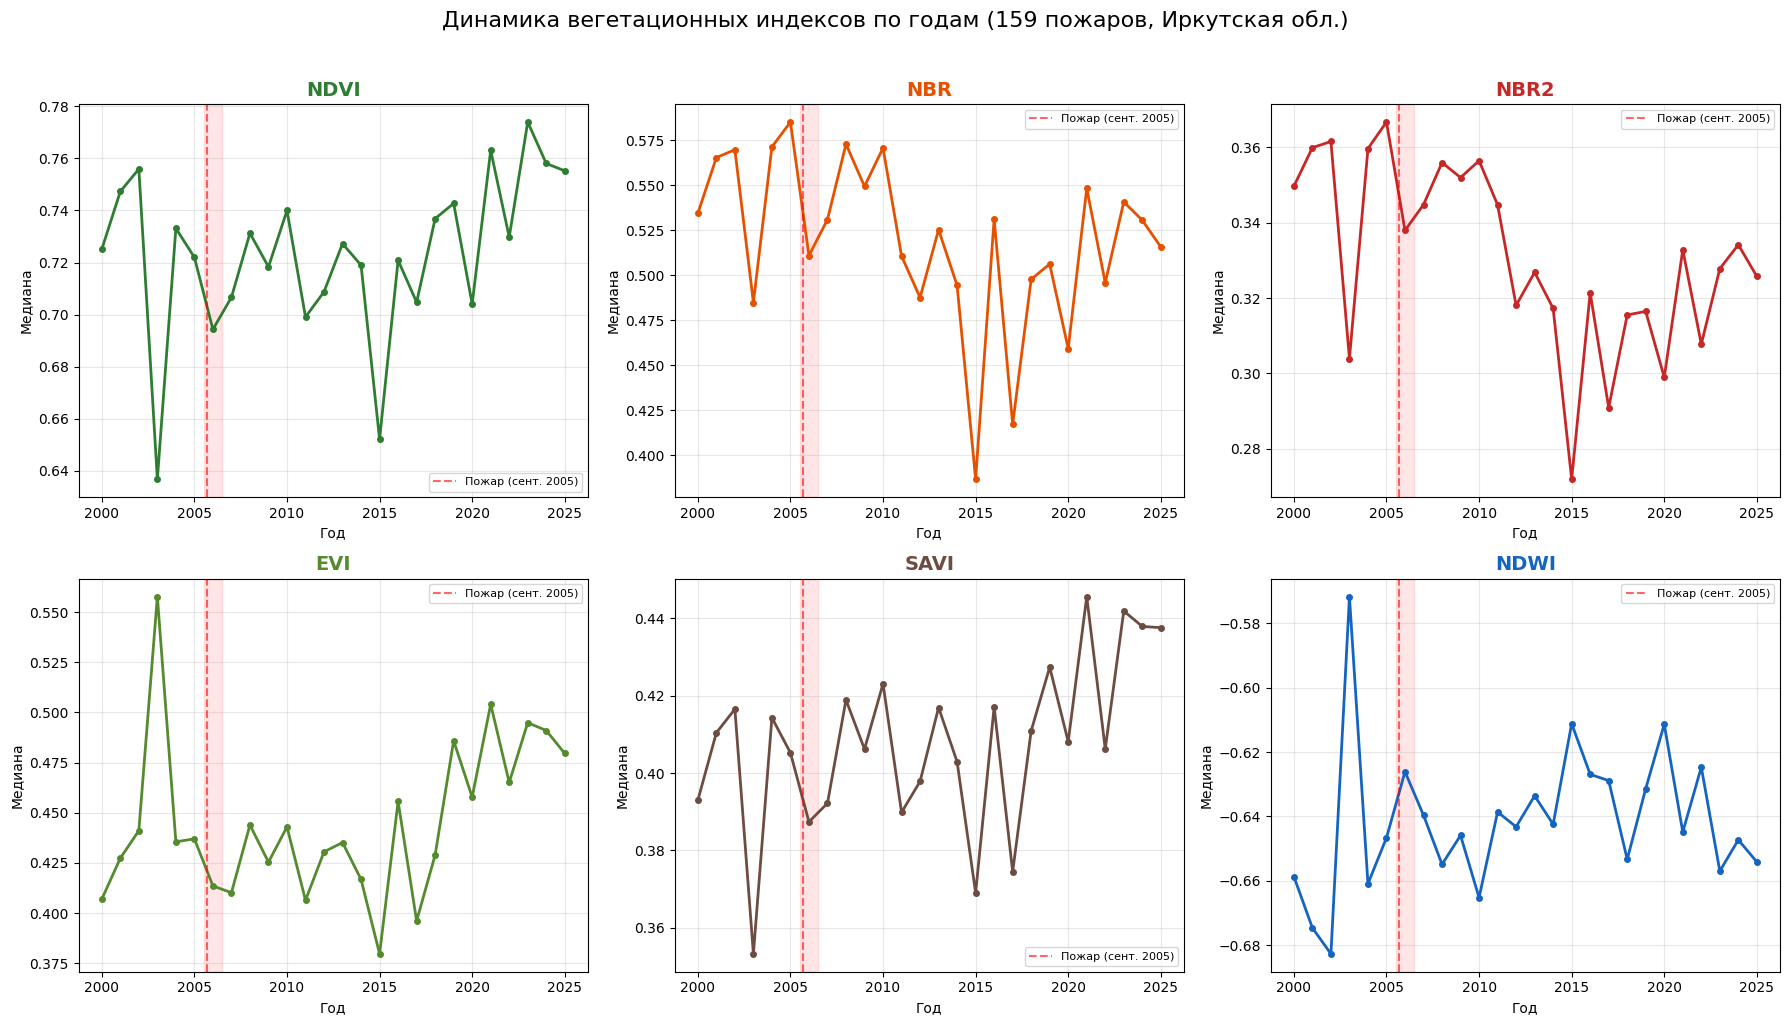

Сохранено: output/vi_dynamics_all.png


In [20]:
vi_median_cols = ['NDVI_median', 'NBR_median', 'NBR2_median', 'EVI_median', 'SAVI_median', 'NDWI_median']
vi_by_year = df_all.groupby('year')[vi_median_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Динамика вегетационных индексов по годам (159 пожаров, Иркутская обл.)', fontsize=16, y=1.02)

colors = {'NDVI':'#2e7d32', 'NBR':'#e65100', 'NBR2':'#c62828', 'EVI':'#558b2f', 'SAVI':'#6d4c41', 'NDWI':'#1565c0'}
for ax, col in zip(axes.flat, vi_median_cols):
    idx_name = col.replace('_median', '')
    ax.plot(vi_by_year.index, vi_by_year[col], 'o-', color=colors[idx_name], linewidth=2, markersize=4)
    ax.axvline(x=2005.7, color='red', linestyle='--', alpha=0.6, label='Пожар (сент. 2005)')
    ax.axvspan(2005.5, 2006.5, alpha=0.1, color='red')
    ax.set_title(f'{idx_name}', fontsize=14, fontweight='bold', color=colors[idx_name])
    ax.set_xlabel('Год')
    ax.set_ylabel('Медиана')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('output/vi_dynamics_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/vi_dynamics_all.png')

### 5.2 Тепловая карта: приоритет изменения индексов по типам растительности

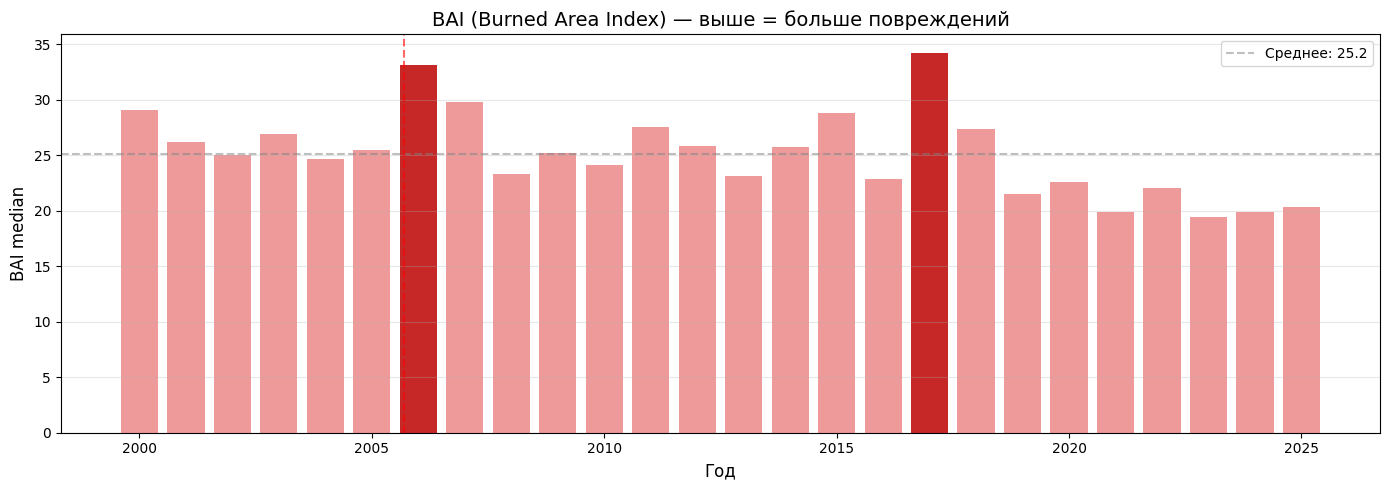

Сохранено: output/bai_dynamics.png

Пик BAI: 2006=33.2, 2017=34.2


In [21]:
bai_by_year = df_all.groupby('year')['BAI_median'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(bai_by_year.index, bai_by_year.values, color=['#c62828' if y in [2006, 2017] else '#ef9a9a' for y in bai_by_year.index])
ax.axhline(y=bai_by_year.mean(), color='gray', linestyle='--', alpha=0.5, label=f'Среднее: {bai_by_year.mean():.1f}')
ax.axvline(x=2005.7, color='red', linestyle='--', alpha=0.6)
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('BAI median', fontsize=12)
ax.set_title('BAI (Burned Area Index) — выше = больше повреждений', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('output/bai_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/bai_dynamics.png')
print(f'\nПик BAI: 2006={bai_by_year.get(2006, 0):.1f}, 2017={bai_by_year.get(2017, 0):.1f}')

### 5.3 Гистограммы распределения NDVI по годам

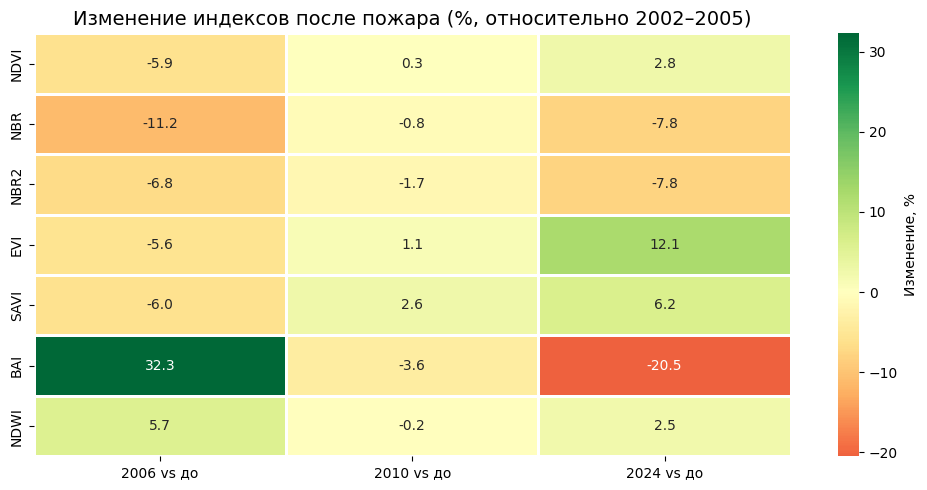

Сохранено: output/heatmap_vi_change.png


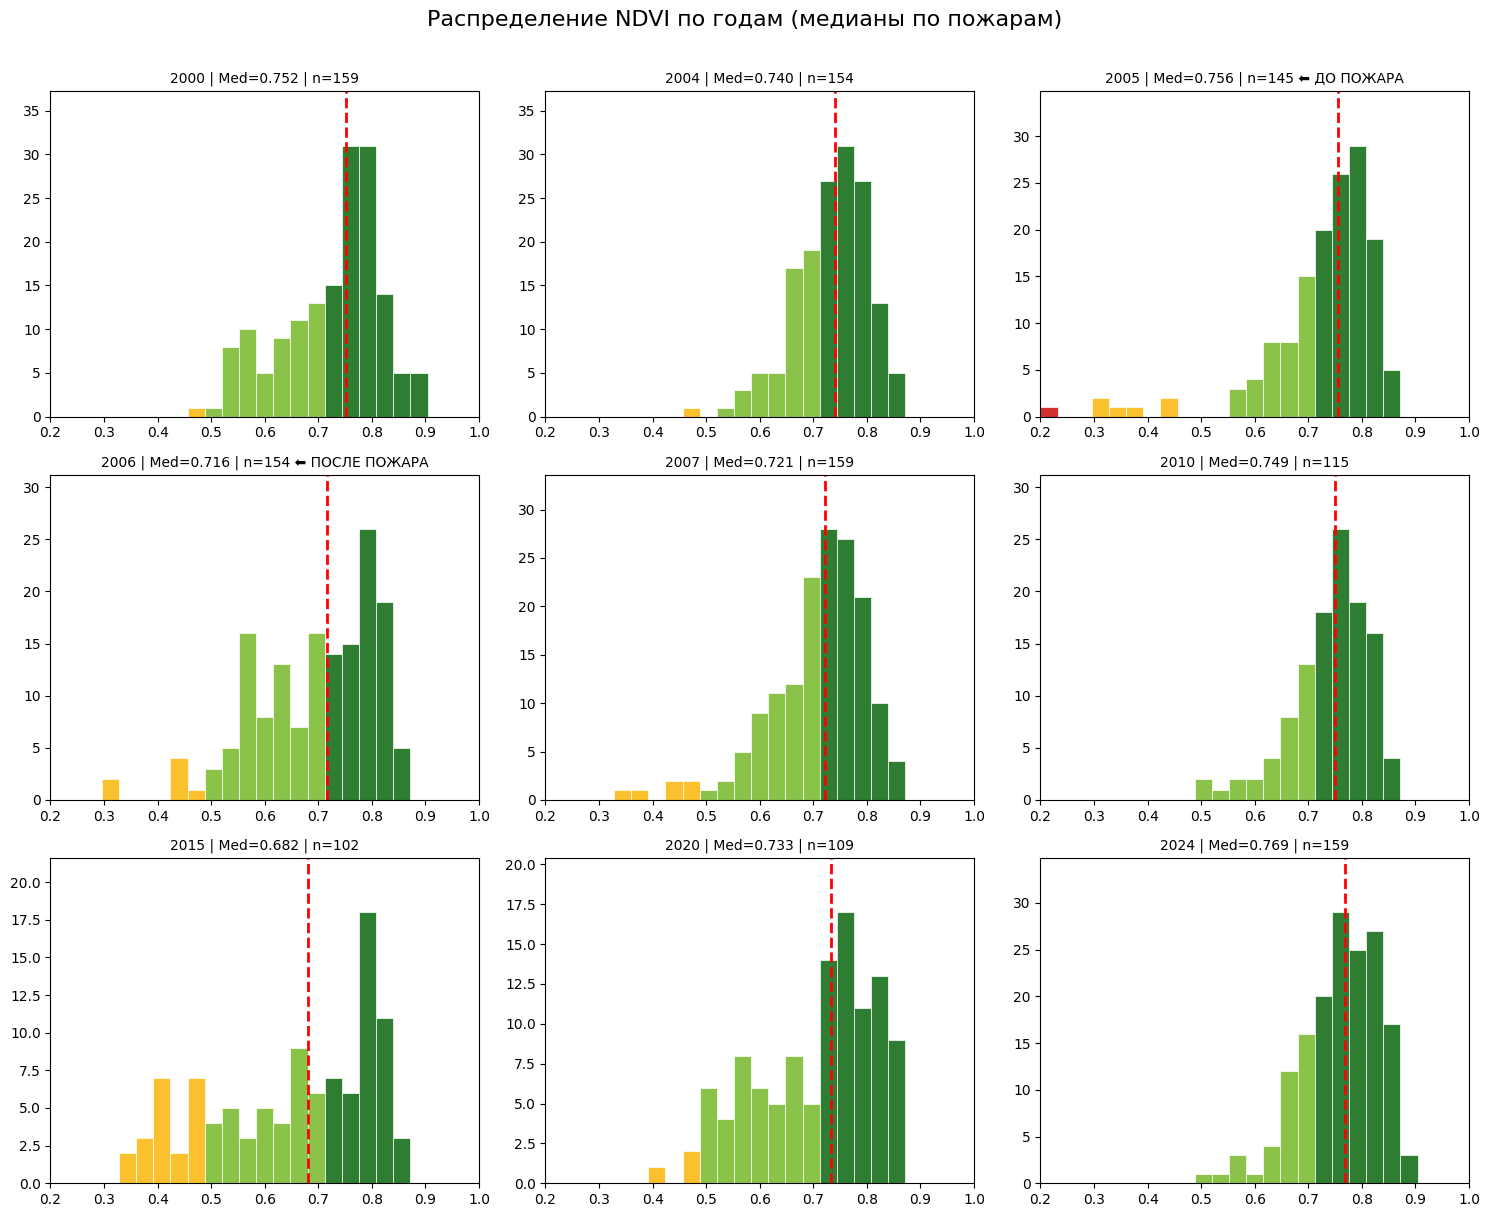

Сохранено: output/ndvi_histograms.png


In [22]:
import seaborn as sns

vi_indices = ['NDVI_median', 'NBR_median', 'NBR2_median', 'EVI_median', 'SAVI_median', 'BAI_median', 'NDWI_median']

pre = df_all[df_all.year.isin([2002, 2004, 2005])][vi_indices].mean()
post_1 = df_all[df_all.year == 2006][vi_indices].mean()
post_5 = df_all[df_all.year == 2010][vi_indices].mean()
post_19 = df_all[df_all.year == 2024][vi_indices].mean()

change_df = pd.DataFrame({
    '2006 vs до': ((post_1 - pre) / pre.abs() * 100).round(1),
    '2010 vs до': ((post_5 - pre) / pre.abs() * 100).round(1),
    '2024 vs до': ((post_19 - pre) / pre.abs() * 100).round(1),
})
change_df.index = [c.replace('_median', '') for c in change_df.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(change_df, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Изменение, %'})
ax.set_title('Изменение индексов после пожара (%, относительно 2002–2005)', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('output/heatmap_vi_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/heatmap_vi_change.png')

years_plot = [2000, 2004, 2005, 2006, 2007, 2010, 2015, 2020, 2024]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Распределение NDVI по годам (медианы по пожарам)', fontsize=16, y=1.01)

def ndvi_color(val):
    if val < 0.3: return '#d32f2f'
    if val < 0.5: return '#fbc02d'
    if val < 0.7: return '#8bc34a'
    return '#2e7d32'

for ax, year in zip(axes.flat, years_plot):
    data = df_all[df_all.year == year]['NDVI_median'].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, f'{year}: нет данных', transform=ax.transAxes, ha='center')
        continue
    n, bins, patches = ax.hist(data, bins=25, range=(0.2, 1.0), edgecolor='white', linewidth=0.5)
    for patch, left in zip(patches, bins[:-1]):
        patch.set_facecolor(ndvi_color(left + 0.015))
    med = data.median()
    ax.axvline(med, color='red', linestyle='--', linewidth=2)
    is_fire = ' ⬅ ПОСЛЕ ПОЖАРА' if year == 2006 else (' ⬅ ДО ПОЖАРА' if year == 2005 else '')
    ax.set_title(f'{year} | Med={med:.3f} | n={len(data)}{is_fire}', fontsize=10)
    ax.set_xlim(0.2, 1.0)
    ax.set_ylim(0, max(n)*1.2 if max(n) > 0 else 10)

plt.tight_layout()
plt.savefig('output/ndvi_histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/ndvi_histograms.png')

### 5.4 Карты NDVI по годам (экспорт из GEE)

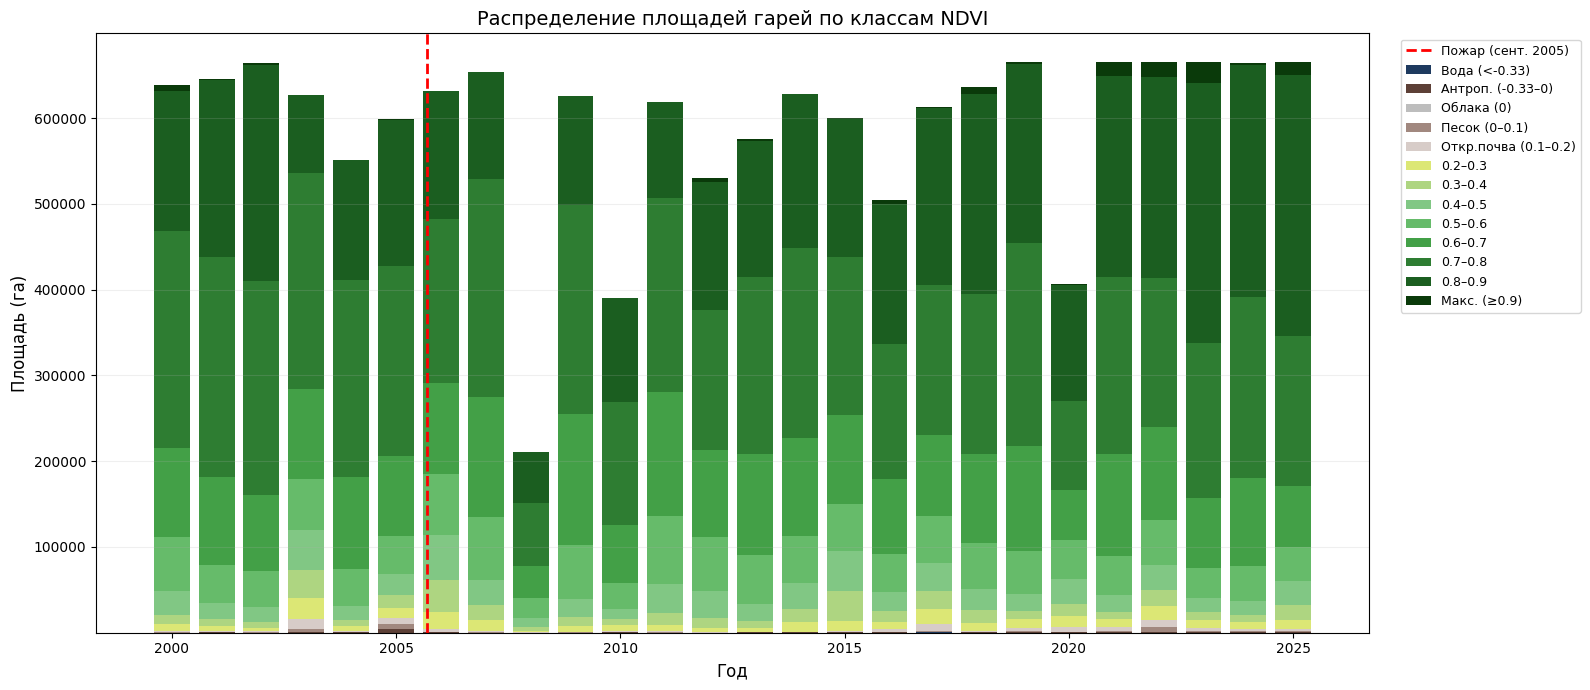

Сохранено: output/ndvi_classes_stacked.png


In [24]:
ndvi_ha_cols = sorted([c for c in df_all.columns if 'ndvi_class_' in c and c.endswith('_ha')])
ndvi_areas = df_all.groupby('year')[ndvi_ha_cols].sum()

cls_labels = {
    'ndvi_class_0_ha': 'Вода (<-0.33)',
    'ndvi_class_1_ha': 'Антроп. (-0.33–0)',
    'ndvi_class_2_ha': 'Облака (0)',
    'ndvi_class_3_ha': 'Песок (0–0.1)',
    'ndvi_class_4_ha': 'Откр.почва (0.1–0.2)',
    'ndvi_class_5_ha': '0.2–0.3',
    'ndvi_class_6_ha': '0.3–0.4',
    'ndvi_class_7_ha': '0.4–0.5',
    'ndvi_class_8_ha': '0.5–0.6',
    'ndvi_class_9_ha': '0.6–0.7',
    'ndvi_class_10_ha': '0.7–0.8',
    'ndvi_class_11_ha': '0.8–0.9',
    'ndvi_class_12_ha': 'Макс. (≥0.9)',
}
cls_colors = ['#1e3a5f','#5d4037','#bdbdbd','#a1887f','#d7ccc8','#dce775','#aed581','#81c784','#66bb6a','#43a047','#2e7d32','#1b5e20','#0a3a0a']

sorted_cols = sorted(ndvi_ha_cols, key=lambda x: int(x.split('_')[2]))

fig, ax = plt.subplots(figsize=(16, 7))
bottom = np.zeros(len(ndvi_areas))
for i, col in enumerate(sorted_cols):
    if col in ndvi_areas.columns:
        label = cls_labels.get(col, col)
        color = cls_colors[i] if i < len(cls_colors) else '#333'
        ax.bar(ndvi_areas.index, ndvi_areas[col], bottom=bottom, label=label, color=color, width=0.8)
        bottom += ndvi_areas[col].values

ax.axvline(x=2005.7, color='red', linestyle='--', linewidth=2, label='Пожар (сент. 2005)')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Площадь (га)', fontsize=12)
ax.set_title('Распределение площадей гарей по классам NDVI', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('output/ndvi_classes_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/ndvi_classes_stacked.png')

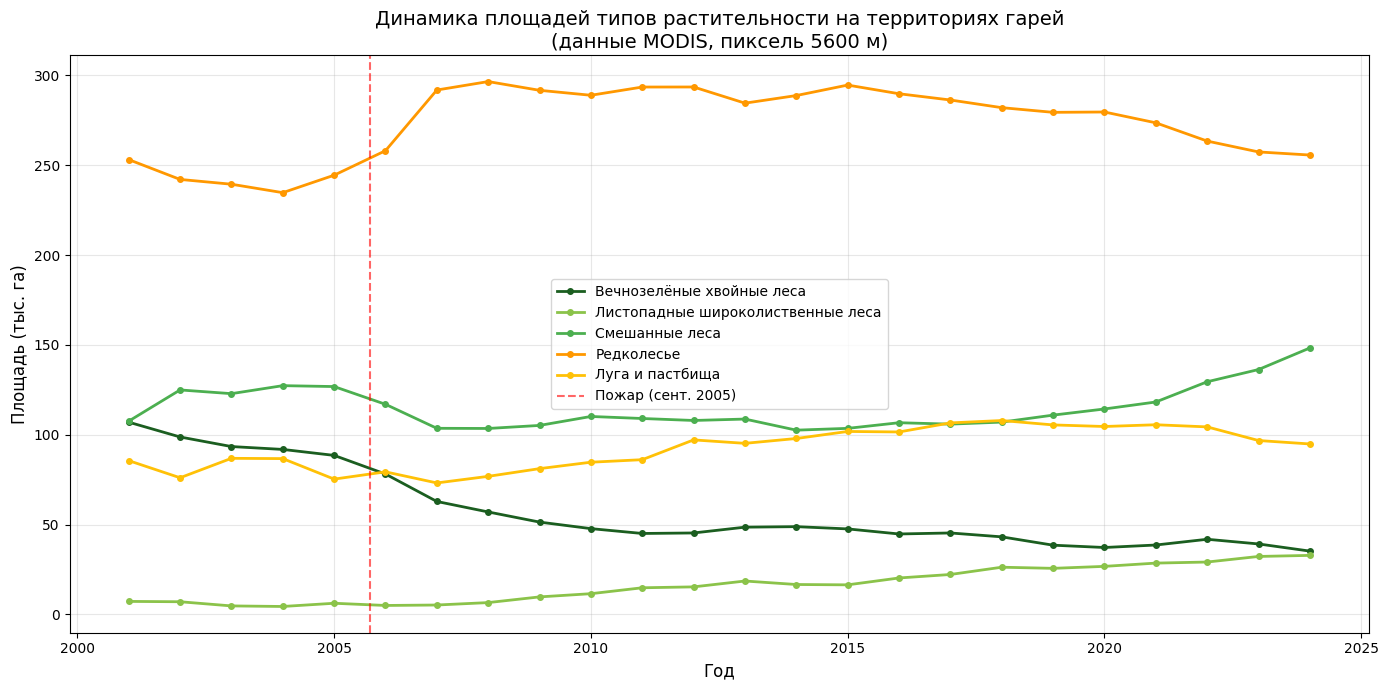

Хвойные 2001→2024: 107000 → 35217 га (−67%)
Лиственные 2001→2024: 7213 → 32834 га (+355%)
Смешанные 2001→2024: 107565 → 148301 га (+38%)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

veg_year = pd.read_excel('data/vegetation_area_by_year.xlsx')

veg_year = pd.read_excel('data/vegetation_area_by_year.xlsx')
veg_year = veg_year.rename(columns={
    'Лесистые саванны': 'Редколесье',
    'Саванны': 'Разреженный древостой',
})

key_types = {
    'Вечнозелёные хвойные леса': '#1b5e20',
    'Листопадные широколиственные леса': '#8bc34a',
    'Смешанные леса': '#4caf50',
    'Редколесье': '#ff9800',
    'Луга и пастбища': '#ffc107',
}

fig, ax = plt.subplots(figsize=(14, 7))
for col, color in key_types.items():
    ax.plot(veg_year['Year'], veg_year[col] / 1000, 'o-', color=color,
            linewidth=2, markersize=4, label=col)

ax.axvline(x=2005.7, color='red', linestyle='--', alpha=0.6, label='Пожар (сент. 2005)')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Площадь (тыс. га)', fontsize=12)
ax.set_title('Динамика площадей типов растительности на территориях гарей\n(данные MODIS, пиксель 5600 м)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/vegetation_types_dynamics.png', dpi=150)
plt.show()

print('Хвойные 2001→2024:', f'{107000:.0f} → {35217:.0f} га (−67%)')
print('Лиственные 2001→2024:', f'{7213:.0f} → {32834:.0f} га (+355%)')
print('Смешанные 2001→2024:', f'{107565:.0f} → {148301:.0f} га (+38%)')

## 6. Экспорт данных для дашборда

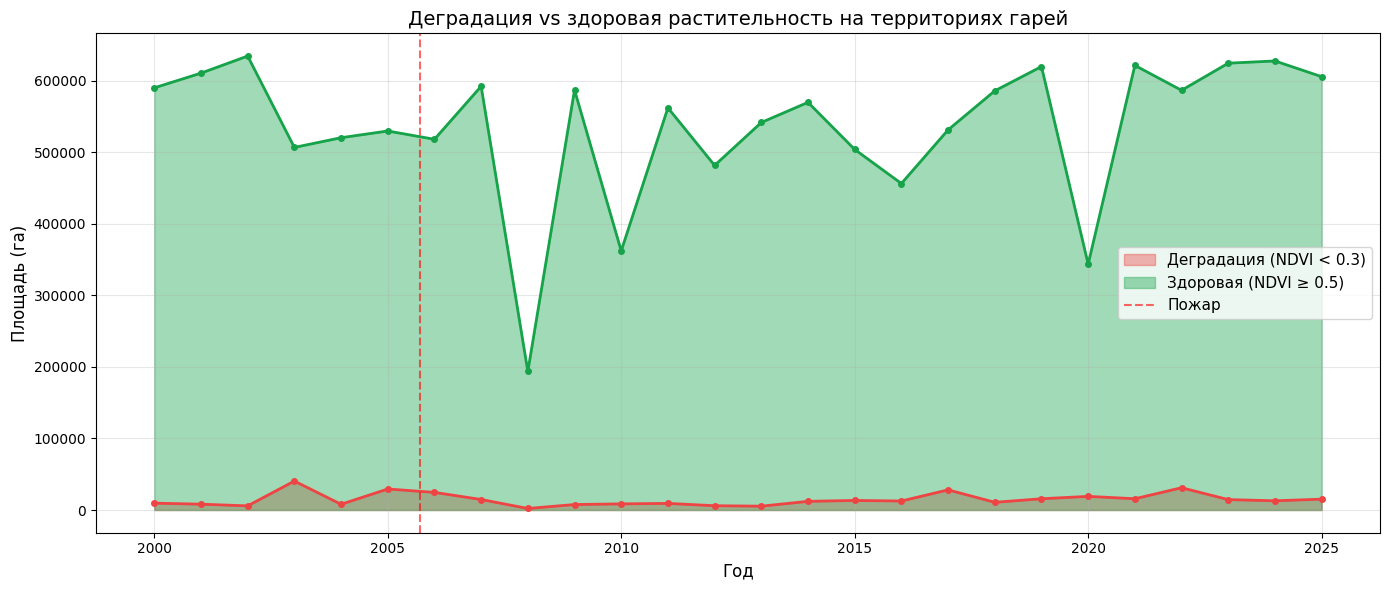

Сохранено: output/degradation_vs_healthy.png


In [25]:
agg = df_all.groupby('year')[['degraded_ha', 'healthy_ha']].sum()

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(agg.index, agg['degraded_ha'], alpha=0.4, color='#ef4444', label='Деградация (NDVI < 0.3)')
ax.fill_between(agg.index, agg['healthy_ha'], alpha=0.4, color='#16a34a', label='Здоровая (NDVI ≥ 0.5)')
ax.plot(agg.index, agg['degraded_ha'], 'o-', color='#ef4444', linewidth=2, markersize=4)
ax.plot(agg.index, agg['healthy_ha'], 'o-', color='#16a34a', linewidth=2, markersize=4)
ax.axvline(x=2005.7, color='red', linestyle='--', alpha=0.6, label='Пожар')
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('Площадь (га)', fontsize=12)
ax.set_title('Деградация vs здоровая растительность на территориях гарей', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/degradation_vs_healthy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/degradation_vs_healthy.png')

## 7. Параметры визуализации индексов (для карт в GEE)

In [26]:
print('=' * 80)
print('СРАВНЕНИЕ КЛЮЧЕВЫХ ПЕРИОДОВ')
print('=' * 80)
print(f'{"Индекс":<10} {"До пожара":>12} {"2006":>12} {"2010":>12} {"2024":>12} {"Δ 2006":>10} {"Δ 2024":>10}')
print('-' * 80)
 
for col in vi_indices:
    idx_name = col.replace('_median', '')
    pre_val = df_all[df_all.year.isin([2002, 2004, 2005])][col].mean()
    y06 = df_all[df_all.year == 2006][col].mean()
    y10 = df_all[df_all.year == 2010][col].mean()
    y24 = df_all[df_all.year == 2024][col].mean()
    d06 = (y06 - pre_val) / abs(pre_val) * 100 if pre_val != 0 else 0
    d24 = (y24 - pre_val) / abs(pre_val) * 100 if pre_val != 0 else 0
    print(f'{idx_name:<10} {pre_val:>12.4f} {y06:>12.4f} {y10:>12.4f} {y24:>12.4f} {d06:>+9.1f}% {d24:>+9.1f}%')
 
print('-' * 80)
print('До пожара = среднее 2002, 2004, 2005 (лето до сентябрьских пожаров)')
print('Δ = процентное изменение относительно допожарного уровня')
 

СРАВНЕНИЕ КЛЮЧЕВЫХ ПЕРИОДОВ
Индекс        До пожара         2006         2010         2024     Δ 2006     Δ 2024
--------------------------------------------------------------------------------
NDVI             0.7375       0.6943       0.7400       0.7581      -5.9%      +2.8%
NBR              0.5751       0.5108       0.5707       0.5305     -11.2%      -7.8%
NBR2             0.3625       0.3379       0.3564       0.3341      -6.8%      -7.8%
EVI              0.4379       0.4135       0.4429       0.4910      -5.6%     +12.1%
SAVI             0.4122       0.3874       0.4231       0.4379      -6.0%      +6.2%
BAI             25.0574      33.1500      24.1626      19.9084     +32.3%     -20.5%
NDWI            -0.6639      -0.6261      -0.6652      -0.6473      +5.7%      +2.5%
--------------------------------------------------------------------------------
До пожара = среднее 2002, 2004, 2005 (лето до сентябрьских пожаров)
Δ = процентное изменение относительно допожарного уровня


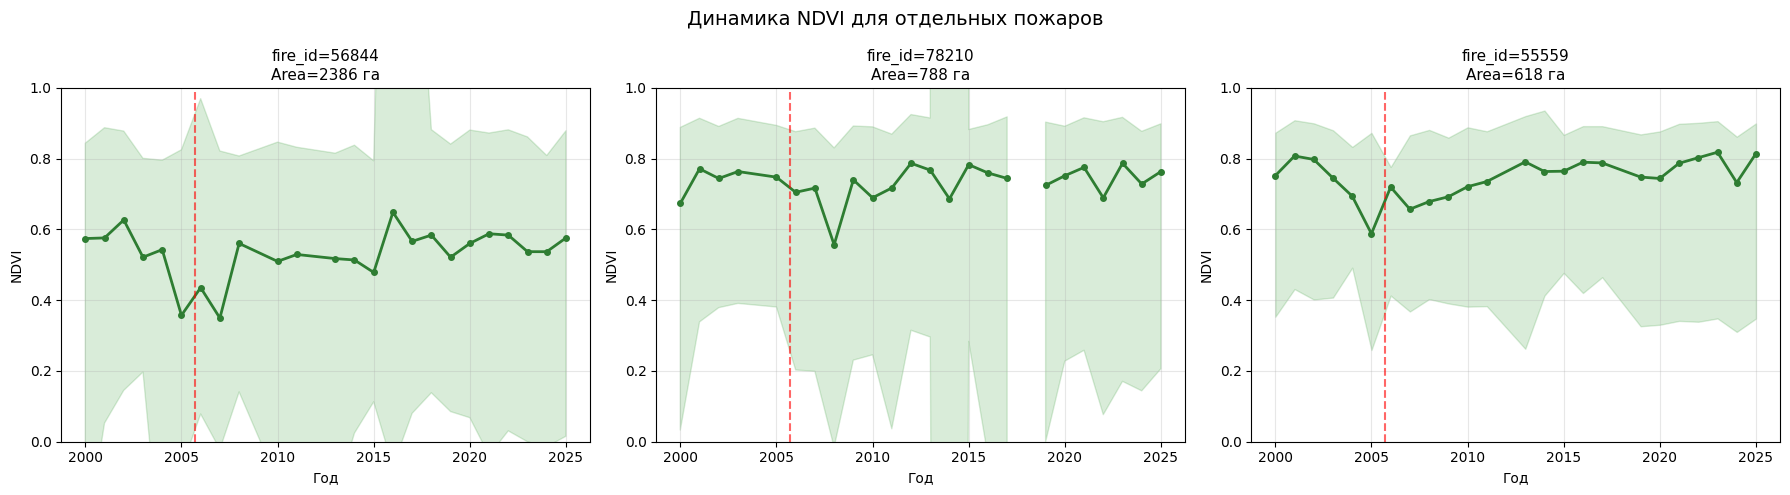

Сохранено: output/sample_fires_ndvi.png


In [27]:
sample_fires = df_all.fire_id.unique()[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Динамика NDVI для отдельных пожаров', fontsize=14)

for ax, fid in zip(axes, sample_fires):
    fire_data = df_all[df_all.fire_id == fid].sort_values('year')
    area = fire_data['Area'].iloc[0] if 'Area' in fire_data.columns else '?'
    ax.plot(fire_data['year'], fire_data['NDVI_median'], 'o-', color='#2e7d32', linewidth=2, markersize=4)
    ax.fill_between(fire_data['year'], fire_data['NDVI_min'], fire_data['NDVI_max'], alpha=0.15, color='green')
    ax.axvline(x=2005.7, color='red', linestyle='--', alpha=0.6)
    ax.set_title(f'fire_id={fid}\nArea={area} га', fontsize=11)
    ax.set_xlabel('Год')
    ax.set_ylabel('NDVI')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('output/sample_fires_ndvi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: output/sample_fires_ndvi.png')

In [28]:
vi_by_year_export = df_all.groupby('year')[[c for c in df_all.columns if c.endswith('_median')]].mean().reset_index()
vi_by_year_export.to_csv('data/dashboard_vi_by_year.csv', index=False)
 
ndvi_ha_export = df_all.groupby('year')[[c for c in df_all.columns if 'ndvi_class' in c and c.endswith('_ha')]].sum().reset_index()
ndvi_ha_export.to_csv('data/dashboard_ndvi_areas.csv', index=False)
 
meta_cols = [c for c in ['fire_id', 'frname', 'Area', 'dt_first', 'dt_last'] if c in df_all.columns]
fires_meta = df_all.groupby('fire_id')[meta_cols[1:]].first().reset_index()
fires_meta.to_csv('data/dashboard_fires_metadata.csv', index=False)
 
import json as json_lib
dashboard_json = {
    'vi_by_year': vi_by_year_export.round(4).to_dict('records'),
    'ndvi_areas': ndvi_ha_export.round(2).to_dict('records'),
}
with open('data/dashboard_data.json', 'w') as f:
    json_lib.dump(dashboard_json, f)
 

In [ ]:
comparison = pd.DataFrame({
    'Все (159)': df_all.groupby('year')['NDVI_median'].mean(),
    'Чистые (38)': df_clean.groupby('year')['NDVI_median'].mean(),
})

print('NDVI по годам:')
print(comparison.round(4).to_string())

for idx_name in ['NBR_median', 'EVI_median', 'BAI_median']:
    comp = pd.DataFrame({
        'Все': df_all.groupby('year')[idx_name].mean(),
        'Чистые': df_clean.groupby('year')[idx_name].mean(),
    })
    print(f'\n{idx_name}:')
    print(comp.round(4).to_string())

df_dirty = df_all[~df_all['is_clean']].copy()
print(f'\nЗаписей с повторными пожарами: {len(df_dirty)} ({df_dirty.fire_id.nunique()} пожаров)')

fig, axes = plt.subplots(2, 2, figsize=(22, 12))

for ax, idx_name, title in zip(axes.flat,
    ['NDVI_median', 'NBR_median', 'EVI_median', 'BAI_median'],
    ['NDVI', 'NBR', 'EVI', 'BAI']):

    all_data = df_all.groupby('year')[idx_name].mean()
    clean_data = df_clean.groupby('year')[idx_name].mean()
    dirty_data = df_dirty.groupby('year')[idx_name].mean()

    ax.plot(all_data.index, all_data.values, 'o-', color='#999', linewidth=1.5,
            markersize=5, label=f'Все 159 пожаров')
    ax.plot(clean_data.index, clean_data.values, 'o-', color='#2e7d32', linewidth=2.5,
            markersize=6, label=f'13 "чистых" пожаров')
    ax.plot(dirty_data.index, dirty_data.values, 's--', color='#c62828', linewidth=2,
            markersize=6, label=f'{df_dirty.fire_id.nunique()} с повторными пожарами')
    ax.axvline(x=2005.7, color='red', linestyle='--', alpha=0.6, label='Пожар (сент. 2005)')
    ax.set_title(title, fontsize=32, fontweight='bold')
    ax.set_xlabel('Год', fontsize=16)
    ax.set_ylabel('Медиана', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(fontsize=13)
    ax.grid(True, alpha=0.3)

fig.suptitle('Все пожары vs "чистые" (без повторных) vs только с повторными', fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('output/clean_vs_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
print('=' * 60)
print('ИТОГОВАЯ СВОДКА ИССЛЕДОВАНИЯ')
print('=' * 60)
print(f'Пожаров: {df_all.fire_id.nunique()}')
print(f'Записей: {len(df_all)}')
print(f'Период: {df_all.year.min()}–{df_all.year.max()}')
print(f'Индексов: NDVI, NBR, NBR2, EVI, SAVI, BAI, NDWI')
 
pre_ndvi = df_all[df_all.year.isin([2002,2004,2005])]['NDVI_median'].mean()
post_ndvi = df_all[df_all.year == 2006]['NDVI_median'].mean()
cur_ndvi = df_all[df_all.year == 2024]['NDVI_median'].mean()
 
print(f'\nNDVI до пожара (2002,2004,2005): {pre_ndvi:.4f}')
print(f'NDVI после пожара (2006):        {post_ndvi:.4f} ({(post_ndvi/pre_ndvi-1)*100:+.1f}%)')
print(f'NDVI 2024:                        {cur_ndvi:.4f} ({(cur_ndvi/pre_ndvi-1)*100:+.1f}%)')
print(f'Восстановление: {cur_ndvi/pre_ndvi*100:.0f}% от допожарного')
 
pre_nbr = df_all[df_all.year.isin([2002,2004,2005])]['NBR_median'].mean()
post_nbr = df_all[df_all.year == 2006]['NBR_median'].mean()
print(f'\nNBR до пожара: {pre_nbr:.4f}')
print(f'NBR после (2006): {post_nbr:.4f} ({(post_nbr/pre_nbr-1)*100:+.1f}%)')
print(f'NBR показывает более сильное падение, чем NDVI — он чувствительнее к пожарам.')
 
print(f'\nПожары начались в СЕНТЯБРЕ 2005.')
print(f'  Летний композит 2005 = ДО пожара.')
print(f'  Первые последствия видны в 2006.')


ИТОГОВАЯ СВОДКА ИССЛЕДОВАНИЯ
Пожаров: 159
Записей: 3863
Период: 2000–2025
Индексов: NDVI, NBR, NBR2, EVI, SAVI, BAI, NDWI

NDVI до пожара (2002,2004,2005): 0.7375
NDVI после пожара (2006):        0.6943 (-5.9%)
NDVI 2024:                        0.7581 (+2.8%)
Восстановление: 103% от допожарного

NBR до пожара: 0.5751
NBR после (2006): 0.5108 (-11.2%)
NBR показывает более сильное падение, чем NDVI — он чувствительнее к пожарам.

Пожары начались в СЕНТЯБРЕ 2005.
  Летний композит 2005 = ДО пожара.
  Первые последствия видны в 2006.
